In [41]:
import os

import torch
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from counterfactual_graph_generation.invariant_maps.maps import invariant_channel_sort
from counterfactual_graph_generation.utils import torch_to_numpy

In [45]:
def fitPCA(z, targets=None, standardize=True, verbose=False):
    z_new = z.reshape(z.shape[0], -1)
    if standardize:
        pipeline = Pipeline([('scaling', StandardScaler()), ('pca', PCA())])
    else:
        pipeline = Pipeline([('pca', PCA())])
    
    pipeline.fit(z_new, targets)
    z_train_pca = pipeline.transform(z_new)
    return z_train_pca, targets, pipeline

def plot_properties(z, targets, description):
    fig, axs = plt.subplots(1)
    fig.set_size_inches(5.3,5)

    divider = make_axes_locatable(axs)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    im = axs.scatter(z[:,0], z[:,1], c=targets, s=10)
    fig.colorbar(im, cax=cax, orientation='vertical')
    axs.title.set_text(description)

    return fig, axs

In [47]:
name = 'aids'
path = os.path.join('../data/predictions' , f'{name}.pt')
latent_variables = torch.load(path)['latent_variables']
for key in latent_variables.keys():
    latent_variables[key] = torch_to_numpy(latent_variables[key])
targets = torch.load(path)['input']['y']
targets = torch_to_numpy(targets).reshape(-1)

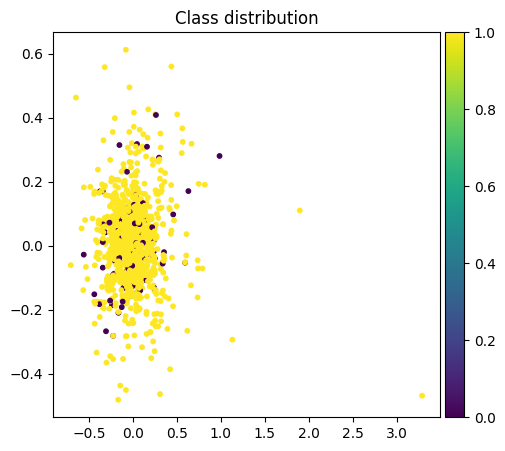

In [64]:
z = latent_variables['mu']
z_sort, z_permutation, z_inv_permutation = invariant_channel_sort(z)
z_train_pca, targets, pipeline = fitPCA(z=z, targets=targets, standardize=False)
fig, axs = plot_properties(z_train_pca, targets, "Class distribution")